<div align="center">
     <font color="blue" size="4">
<h1>CAR SELLING PRICE PREDICTION</h1>
</div>

<font size="4"><b>Target</b> : 
To predict the price of car using all the necessary and relevant features that are provided in the dataset. (Regression Problem)</font>

<font size="4"><b>Part 1 : OutLine<b></font>

1. Importing all Necessary Libraries.
2. Loading and Understanding Dataset.
3. Checking Null Values and Filling all Null values.
4. Creating Final Data set.
5. Categorical Variable Conversion using One Hot Encoding.
6. Corelation between different variable using Pair Plot and Heat map(Visualization).
7. Seprating Final Data set into dependent(y) and independent (x) column for modelling. 

# Importing Necessary Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
import missingno as ms 

# Loading and Understandig Dataset

In [4]:
df=pd.read_csv("car_prediction_data.csv")

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape # to check number of rows and columns

(301, 9)

In [7]:
df.describe() # to see the basic Statistics of numerical data 

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.describe(include="object") #to see the basic Statistics of categorical data 

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [9]:
df.info() # checking the data types and basic infor about all columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


### CHECKING THE UNIQUE NUMBER and VALUES FOR ALL THE CATEGORICAL VARIABLE 

In [10]:
print(df["Fuel_Type"].unique())
print("#_________________________________________________________#")
print("No of Unique values:",df["Fuel_Type"].nunique())

['Petrol' 'Diesel' 'CNG']
#_________________________________________________________#
No of Unique values: 3


In [11]:
print(df["Seller_Type"].unique())
print(df["Seller_Type"].nunique())

['Dealer' 'Individual']
2


In [12]:
print(df["Owner"].unique())
print(df["Owner"].nunique())

[0 1 3]
3


In [13]:
print(df["Transmission"].unique())
print(df["Transmission"].nunique())

['Manual' 'Automatic']
2


###  Finding The Number of NULL values in Each Column 

In [14]:
df.isnull().sum # null values in each column

<bound method DataFrame.sum of      Car_Name   Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0       False  False          False          False       False      False   
1       False  False          False          False       False      False   
2       False  False          False          False       False      False   
3       False  False          False          False       False      False   
4       False  False          False          False       False      False   
..        ...    ...            ...            ...         ...        ...   
296     False  False          False          False       False      False   
297     False  False          False          False       False      False   
298     False  False          False          False       False      False   
299     False  False          False          False       False      False   
300     False  False          False          False       False      False   

     Seller_Type  Transmission  Owner  
0   

In [15]:
df.isnull().sum().sum() # sum of all null values

0

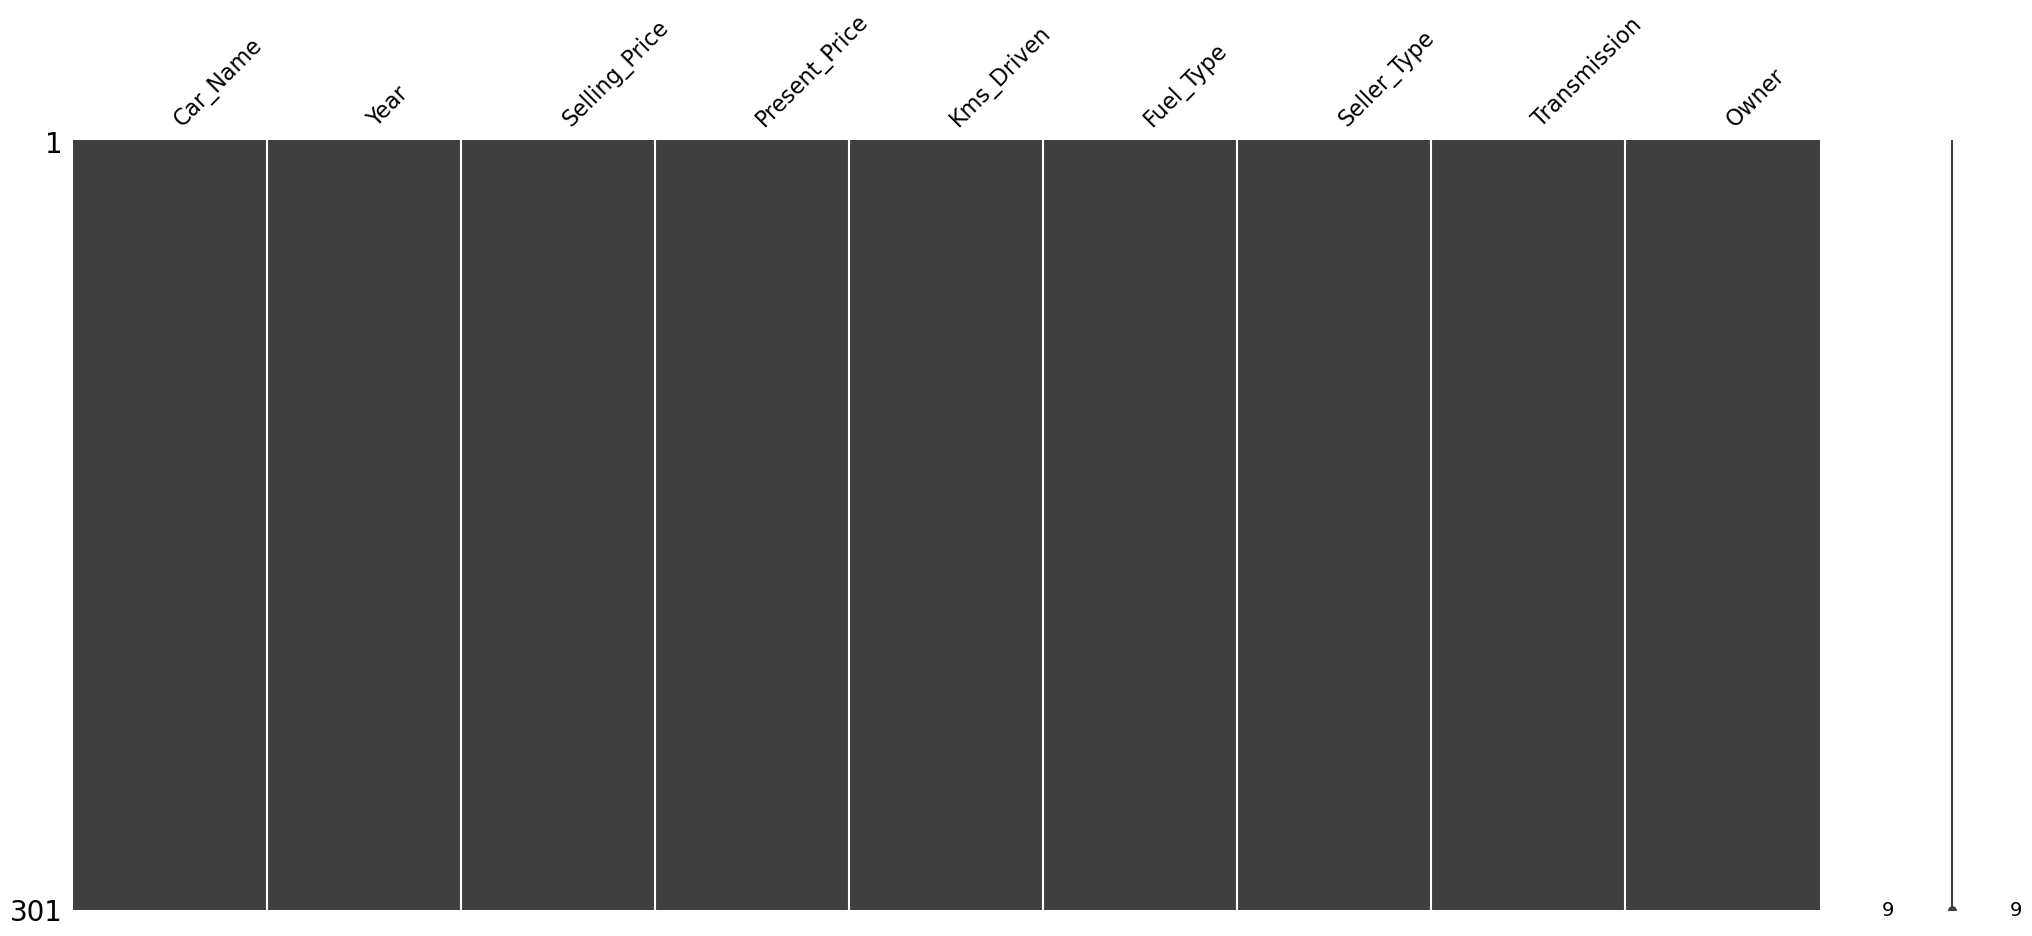

In [16]:
# Using  missingno to visualize the missing values in each column

ms.matrix(df)
plt.show()

## Creating a Final Data Set in Which We Will Exclude the *CAR* Name.

In [17]:
final_dataset=df[['Year','Selling_Price','Present_Price','Kms_Driven','Fuel_Type','Seller_Type','Transmission','Owner']]

In [18]:
final_dataset=pd.DataFrame(final_dataset)

In [19]:
final_dataset.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


####  Adding  new column to the final_dataset to get the actual year of car 

In [20]:
final_dataset["Current_Year"]=2021 #considering base year as 2021

In [21]:
final_dataset.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Current_Year
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2021
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2021
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2021
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2021
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2021


In [22]:
final_dataset["no_year"]=final_dataset["Current_Year"]-final_dataset["Year"] # getting how old car is with  base year as 2021

In [23]:
final_dataset.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Current_Year,no_year
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2021,7
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2021,8
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2021,4
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2021,10
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2021,7


In [24]:
# drop the year column  as it is of not much use 

In [25]:
final_dataset.drop(["Year"],axis=1,inplace=True)

In [26]:
final_dataset.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Current_Year,no_year
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,2021,7
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,2021,8
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2021,4
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,2021,10
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,2021,7


#### Converting CATEGORICAL variable into  machine learning readable form by using ONE HOT ENCODING

In [27]:
final_dataset=pd.get_dummies(final_dataset,drop_first=True,dtype=int)

In [28]:
final_dataset.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Current_Year,no_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,2021,7,0,1,0,1
1,4.75,9.54,43000,0,2021,8,1,0,0,1
2,7.25,9.85,6900,0,2021,4,0,1,0,1
3,2.85,4.15,5200,0,2021,10,0,1,0,1
4,4.60,6.87,42450,0,2021,7,1,0,0,1


In [29]:
final_dataset=final_dataset.drop(["Current_Year"],axis=1)

In [30]:
final_dataset.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,no_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,7,0,1,0,1
1,4.75,9.54,43000,0,8,1,0,0,1
2,7.25,9.85,6900,0,4,0,1,0,1
3,2.85,4.15,5200,0,10,0,1,0,1
4,4.60,6.87,42450,0,7,1,0,0,1


In [31]:
final_dataset.shape

(301, 9)

In [32]:
### Calculating the CO-RELATION  to know the strength of relation between all the attributes

In [33]:
# correlation
print("CORRERALATION TABLE")
print("--------------------------------------------------------------------------------------------------------------------------------------")
final_dataset.corr()


CORRERALATION TABLE
--------------------------------------------------------------------------------------------------------------------------------------


,Selling_Price,Present_Price,Kms_Driven,Owner,no_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Selling_Price,1.000000,0.878983,0.029187,-0.088344,-0.236141,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,0.878983,1.000000,0.203647,0.008057,0.047584,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,0.029187,0.203647,1.000000,0.089216,0.524342,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.088344,0.008057,0.089216,1.000000,0.182104,-0.053469,0.055687,0.124269,-0.050316
no_year,-0.236141,0.047584,0.524342,0.182104,1.000000,-0.064315,0.059959,0.039896,-0.000394
Fuel_Type_Diesel,0.552339,0.473306,0.172515,-0.053469,-0.064315,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.540571,-0.465244,-0.172874,0.055687,0.059959,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.550724,-0.512030,-0.101419,0.124269,0.039896,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.367128,-0.348715,-0.162510,-0.050316,-0.000394,-0.098643,0.091013,0.063240,1.000000


### PairPlot to get the correlation in visualization form 

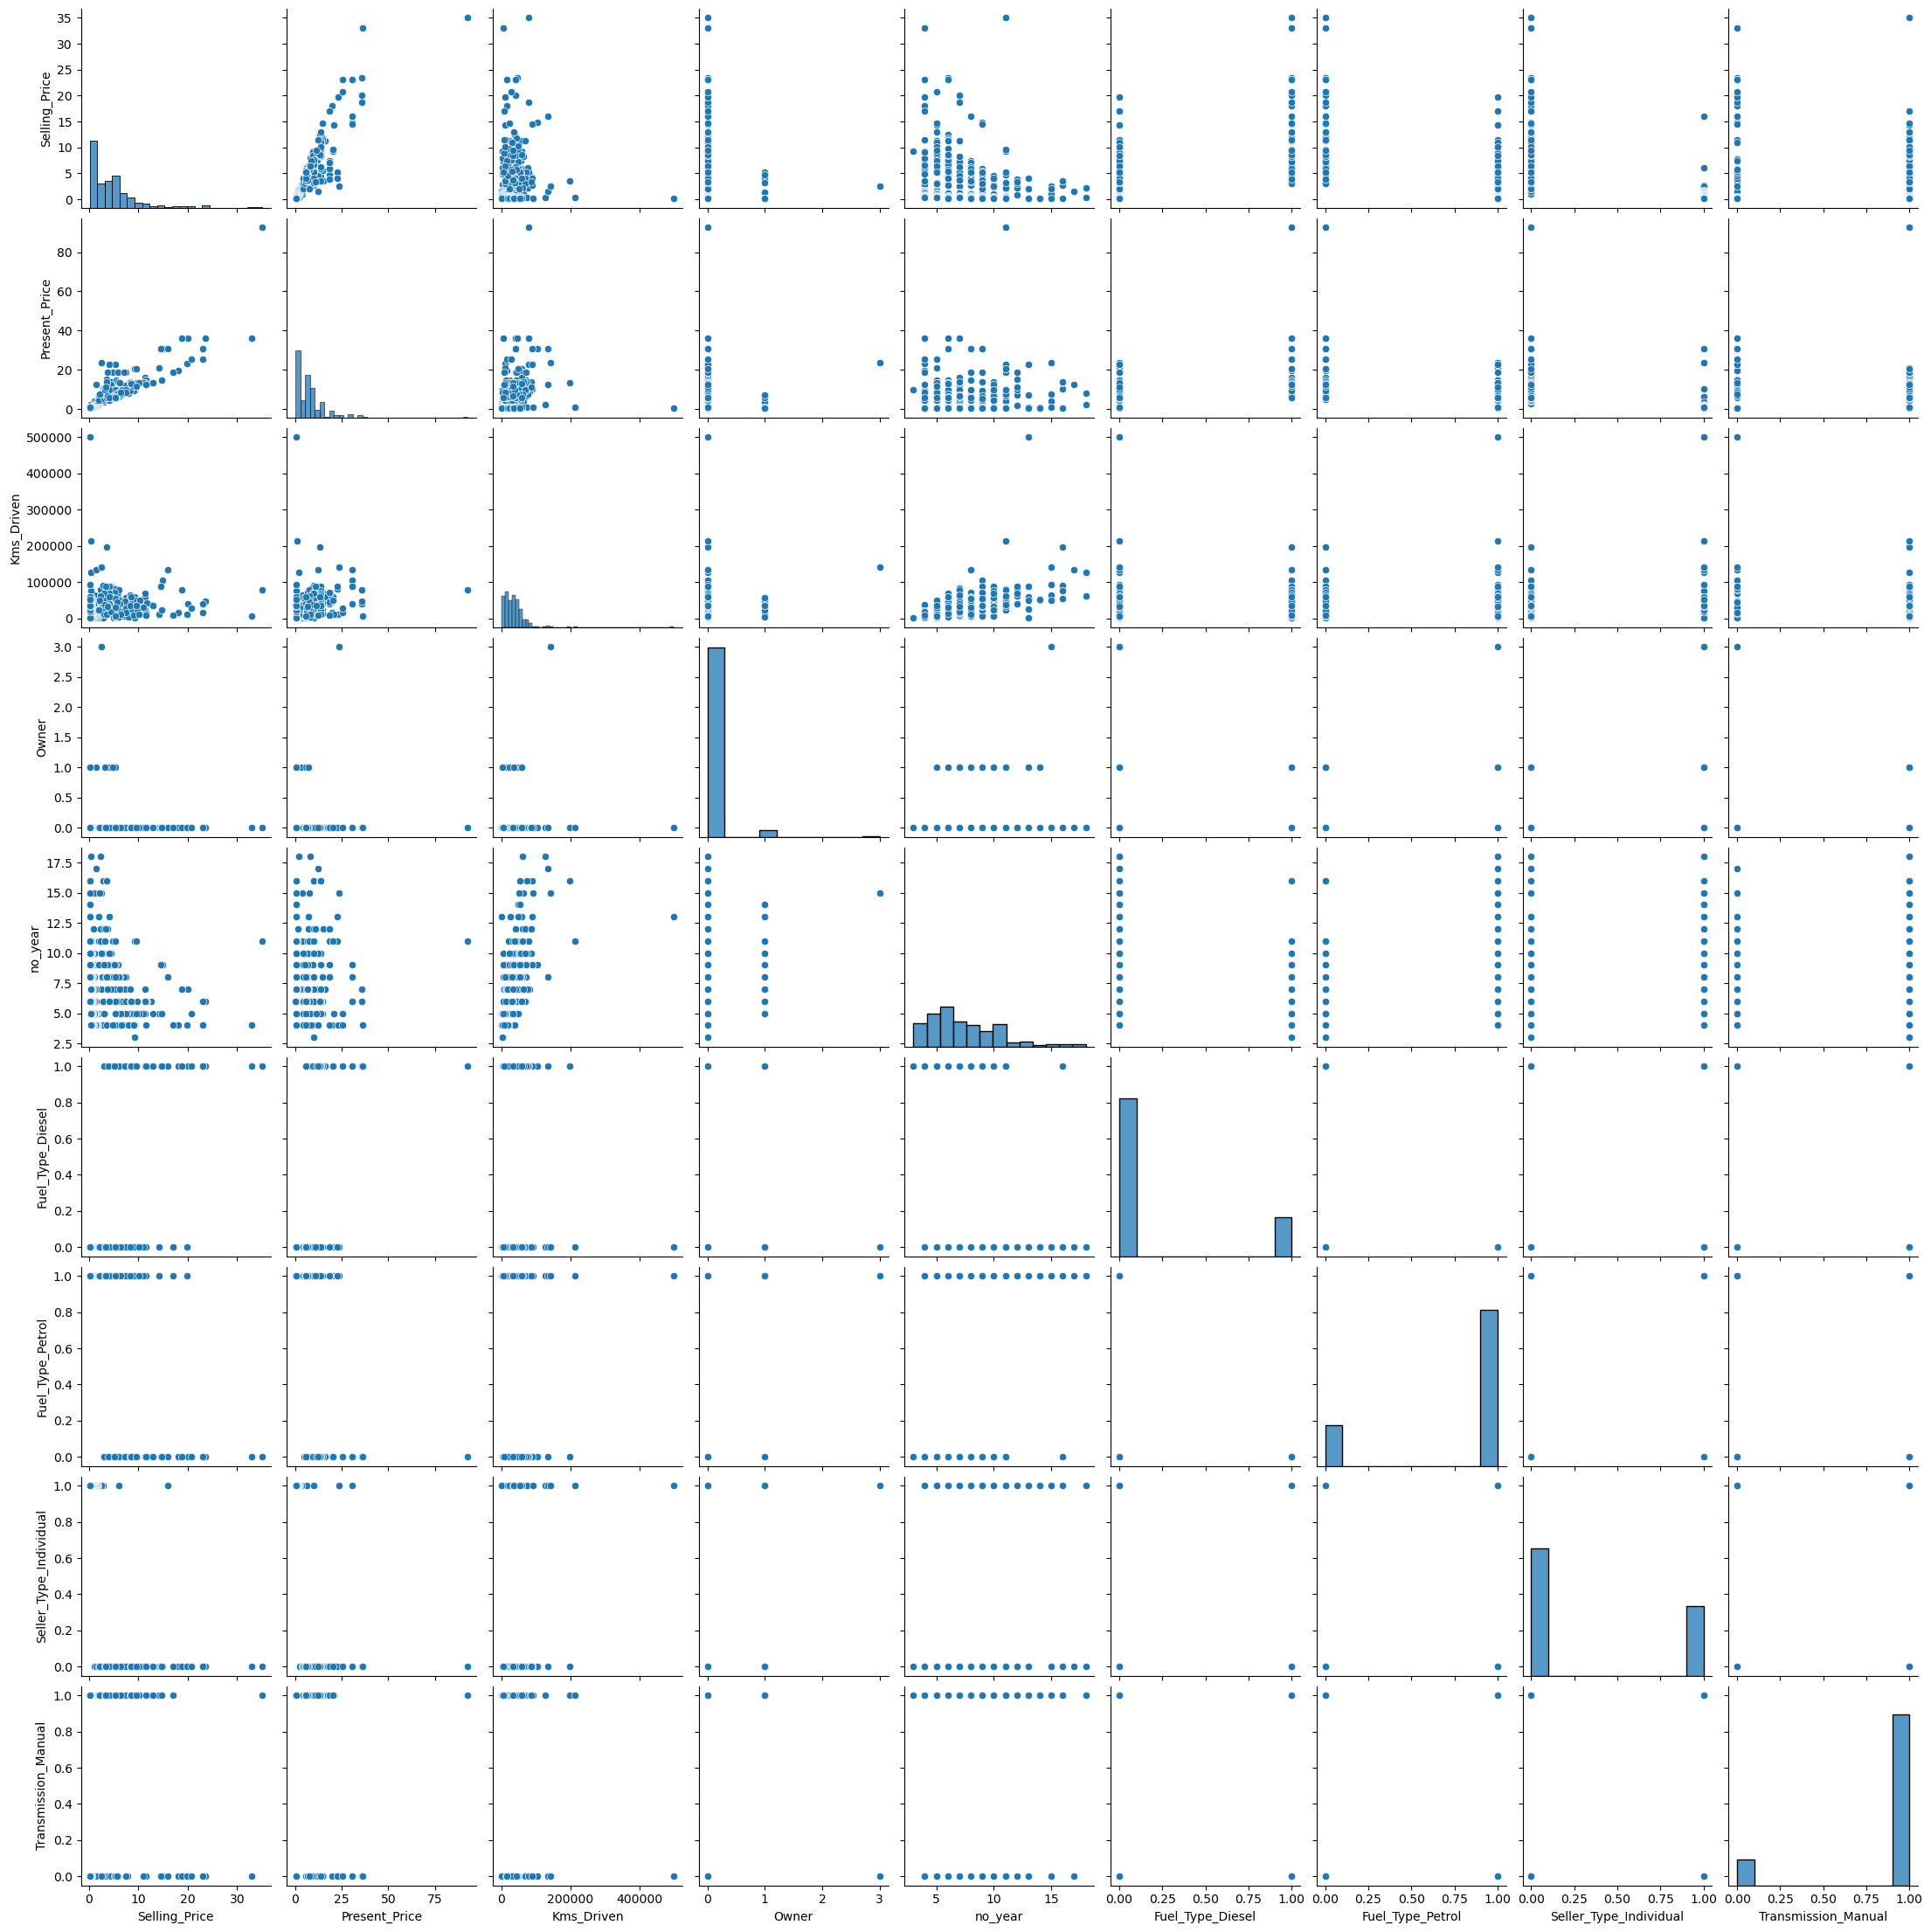

In [34]:
sns.pairplot(final_dataset)
plt.show()

### Heat map to visualize the correlation by using color coding

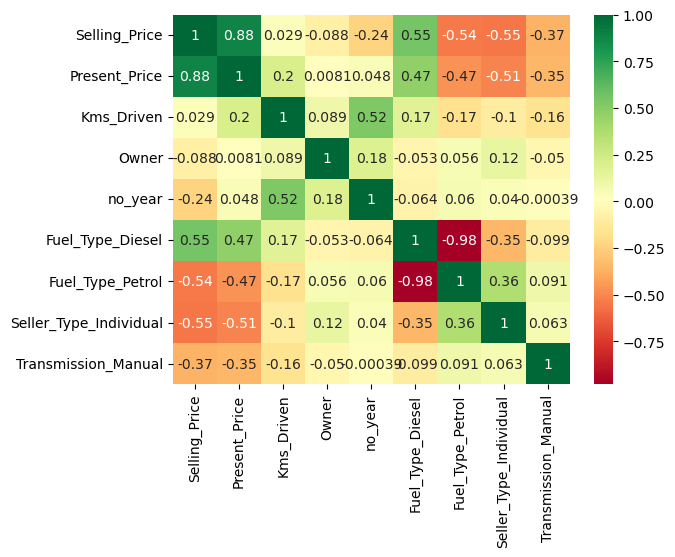

In [35]:
corrmat=final_dataset.corr()
top_corr_features = corrmat.index
g=sns.heatmap(final_dataset[top_corr_features].corr(),annot=True,cmap="RdYlGn")


In [36]:
# now lets seprate the dataset --- dependent and independet columns seprately 

In [37]:
X=final_dataset.iloc[:,1:]
y=final_dataset.iloc[:,0]

In [38]:
X.head() # Attributes  save in X

,Present_Price,Kms_Driven,Owner,no_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,7,0,1,0,1
1,9.54,43000,0,8,1,0,0,1
2,9.85,6900,0,4,0,1,0,1
3,4.15,5200,0,10,0,1,0,1
4,6.87,42450,0,7,1,0,0,1


In [39]:
y.head() # Attributes Savd in Y

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

<div align="center">
<font size="10">END OF PART 1 </font>
</div>

### For medelling refer to Part 2